# Agentic AI - Planning Pattern


A pattern where an Large Language Model (LLM) agent autonomously break down a complex, multi-step goal into a sequential plan of smaller, actionable subtasks before starting execution.

Planning pattern is more powerful when we use with Tool use pattern to communicate with external calls. However, it is totally depends upon use case what kinds of pattern we have to use to solve the problem.

## Ollama Setup
So we will be using open source models from ollama as an llm/slm call to understand the concept

In [2]:
%%capture
# let's download the ollama executables
!curl -fsSL https://ollama.com/install.sh | sh


In [37]:
# serve the ollama
!nohup ollama serve &

nohup: appending output to 'nohup.out'


In [4]:
# pull the llm/slm models
# !ollama pull smollm:135m
# !ollama pull embeddinggemma:300m
# !ollama pull tinyllama:1.1b
# !ollama pull gemma3:270m
!ollama pull gemma3:1b # good at natural language understading


In [32]:
# list the pulled models
!ollama list

NAME         ID              SIZE      MODIFIED       
gemma3:1b    8648f39daa8f    815 MB    36 minutes ago    


## LangChain/LangGraph Framework
we will be using langchain framework to implement the agents

In [6]:
# Installing required libraries
%%capture

!pip install langchain
!pip install langchain-ollama
!pip install langchain-core
!pip install langgraph
!pip install mermaid-py
!pip install pprintpp

In [7]:

# importing required libs

from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.tools import tool
from typing import TypedDict, Annotated
from IPython.display import Image
from pprint import pprint
import re
import random
import json
import operator
import json

In [55]:
gemma_llm = ChatOllama(model="gemma3:1b", temperature=0.1) # good at understanding in natural language processing

**Use Case:** Here we are going to create a planner and an executor for understadning of the debug log and suggest the resolution steps.

Planner: Planner node will plan and list the steps to resolve the issue.

Executor: Executor node will take plan one by one and try to suggest the resolution for it.

Let's see how we can achieve this.

In [67]:
# defining class and nodes

# an agent class to maintain the state between nodes
class AgentState(TypedDict):
  messages : Annotated[list[AIMessage | HumanMessage | ToolMessage], operator.add]
  plan: list[str]
  user_query: str
  past_steps : Annotated[list[str], operator.add]
  final_output: str
  plan_and_suggestion: Annotated[list[dict], operator.add]
  is_topic_related: bool

# a class to define the structure for planner node output
class Plan(BaseModel):
  steps: list[str]  = Field(
    description="List of concise, sequential steps to resolve the issue."
  )

# a class to define the structure for executor node output
class Resolution(BaseModel):
  resolution: str  = Field(
    description="A string content to determine the resolution about the given plan issue."
  )


# a class to define the structure for classifier node output
class Classifier(BaseModel):
  is_input_related: bool  = Field(
    description="A bool value that contains either True or False to determine if user input is related to the technologies or not."
  )



In [68]:
# adding a node to determine if user input is related to computer tech or not, as planner is getting hallucinated with input

def classify_user_input(state:AgentState):

  classifier_llm_system_prompt = """Act as a experienced analyzer of user input to determine if it is related to error logs or not.
  Your output must be a boolean value.
  If user input is related to computer technologies, such as error logs, warning logs, some issue etc then response must be True.
  Here are the few keywords that helps to determine error logs: module not found, TypeError, Syntax Error, index out of range etc.
  Return False if topic is not related to computer tech.
  Avoid adding system logs."""

  classifier_llm_chain = ChatPromptTemplate.from_messages([
      ("system", classifier_llm_system_prompt),
      ("human" , "{user_query}")
  ]) | gemma_llm.with_structured_output(Classifier)


  classifier_llm_response = classifier_llm_chain.invoke({"user_query": state["user_query"]})

  return {"is_topic_related": classifier_llm_response.is_input_related}

In [69]:
# preparing prompt for planner node
planner_llm_system_prompt = """Act as an experienced tech engineer with excellent skills to debug the only technology related issues.
Remember! If input is NOT RELATEDD to computer technologies, then NO NEED TO SUGGEST ANY PLAN TO RESOLVE. Just return empty list for plan.
You have to understand the issue from the given input and determine the steps to resolve the issue. List Only steps not the resolution.
Always think step-by-step. Do not use system logs.

"""

# defining the node to understand the user query and determine the steps to identify the issue
def planner_determine_resolution_steps(state:AgentState):

  # let's check if topic is related or not
  if state["is_topic_related"]:
    planner_llm_chain = ChatPromptTemplate.from_messages([
        ("system", planner_llm_system_prompt),
        ("human",  "{user_query}")

    ]) | gemma_llm.with_structured_output(Plan)

    # setting structured output

    planner_llm_response =  planner_llm_chain.invoke({"user_query" : state["user_query"]})

    try:
      output =  {
          "plan": planner_llm_response.steps,
          "past_steps": ["Planning", "Plan Generated"]
      }
      return output

    except:
      return  {
          "plan": [],
          "past_steps": ["Planning", "Plan Failed"]
      }

  else:
    return  {
          "plan": [],
          "past_steps": ["Planning", "Plan Unrelated"]
      }



In [70]:
# preparing prompt for executor node and defining the node structure

executor_llm_system_prompt = """Execute the current step of the given plan as 'Goal'.
Suggest only 2 sentences to address the issue mentioned in the input.
Do not use system logs.
"""


# defining the node to understand the patient's concerns related to health
def executor_suggested_resolution(state:AgentState):
  """ Executes the next step in the current plan"""

  # reading the plan determined by planner
  all_plans = state["plan"]

  # checking if plan is determined or not
  if not all_plans:
    return {"past_steps": ["Plan is empty. Proceeding to final answer."]}

  # if valid then reading the first plan
  current_plan = all_plans[0]

  # executor llm chain
  executor_llm_chain = ChatPromptTemplate.from_messages([
      ("system",executor_llm_system_prompt),
      ("ai",  f"Goal: {current_plan}")

  ]) | gemma_llm.with_structured_output(Resolution)

  executor_llm_result = executor_llm_chain.invoke({})

  # left plans - removing the first one and modifying rest
  left_plan = all_plans[1:]

  try:
    llm_suggestion = executor_llm_result.resolution
  except:
    llm_suggestion = "Errored"


  output =  {
      "plan": left_plan,
      "past_steps": [f"Plan Executed:: {current_plan}"],
      "plan_and_suggestion": [{"plan": current_plan, "suggestion": llm_suggestion}]
  }

  return output




In [76]:
# creating a node to prepare the final output
def format_final_output(state:AgentState):
  related_topic = state["is_topic_related"]
  past_steps = state["past_steps"]
  plan_n_suggestion = state["plan_and_suggestion"]

  # checking if plan failed at initial stage
  if past_steps.count("Plan Failed") > 0:
    return {"final_output" : "Apologies! Plan Failed. Workflow is unable to understand the query and propose the steps to resolve the issue"}


  # now, plan is generated so let's list the plan and suggestion
  elif related_topic:

    return {"final_output" : f"""On the basis of given query, workflow has identified few findings and suggestions which might help to torubleshoot issue.
    Kindly find below details:

    {"".join([f"Finding:: {item["plan"]} \nSuggestion:: {item["suggestion"]}\n\n" for item in plan_n_suggestion])}
    """}

  else:
    return {"final_output" : "Oops! Workflow determined that input is not related to any logs."}

In [61]:
# creating router to execute the executor or exit

def do_processing(state:AgentState):
  if state["plan"]:
    return "continue"
  else:
    return "prepare_final_output"

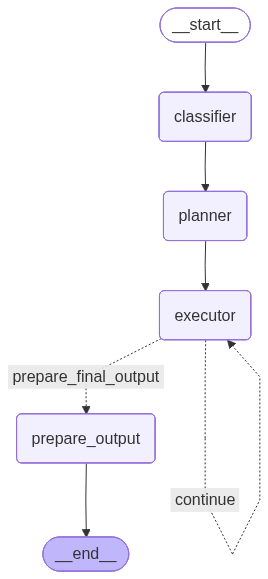

In [77]:
# let's consturct the graph

plannerGraph = StateGraph(AgentState)


# adding nodes
plannerGraph.add_node("classifier", classify_user_input)
plannerGraph.add_node("planner", planner_determine_resolution_steps)
plannerGraph.add_node("executor", executor_suggested_resolution)
plannerGraph.add_node("prepare_output", format_final_output)


# adding edges
plannerGraph.add_edge(START, "classifier")
plannerGraph.add_edge("classifier", "planner")
plannerGraph.add_edge("planner", "executor")

# adding conditional edge to loop through or prepare the output
plannerGraph.add_conditional_edges("executor", do_processing, {
    "continue": "executor",
    "prepare_final_output": "prepare_output"
})

plannerGraph.add_edge("prepare_output", END)

plannerWorkflow = plannerGraph.compile()

# let's visualize the graph
Image(plannerWorkflow.get_graph().draw_mermaid_png())


Nice, let's invoke the workflow and let's see how it works

In [73]:
user_query = """ ---------------------------------------------------------------------------
FileNotFoundError                         Traceback (most recent call last)
/tmp/ipython-input-1618537612.py in <cell line: 0>()
      3   if a:
----> 4     print(open("asldihasd.html"))
      5 except Exception as e:

FileNotFoundError: [Errno 2] No such file or directory: 'asldihasd.html'

During handling of the above exception, another exception occurred:

TypeError                                 Traceback (most recent call last)
/tmp/ipython-input-1618537612.py in <cell line: 0>()
      4     print(open("asldihasd.html"))
      5 except Exception as e:
----> 6   print(e, traceback(e))

TypeError: 'module' object is not callable
"""

workflow_output = plannerWorkflow.invoke({"user_query" : user_query})
print(workflow_output['final_output'])

On the basis of given query, workflow has identified few findings and suggestions which might help to torubleshoot issue.
    Kindly find below details:

    Finding:: Check if the file 'asldihasd.html' exists in the current directory or in the same directory as the script. 
Suggestion:: Verify the presence of the specified file.

Finding:: If the file does not exist, attempt to create it using a file creation tool. 
Suggestion:: high

Finding:: If the file exists, verify that the file is accessible and does not contain any errors. 
Suggestion:: Ensure the file is properly formatted and can be opened for inspection.


    


let's see complete output, not if you need to see update/values in intermediate steps please use stream along with proper stream_mode

In [74]:
pprint(workflow_output)

{'final_output': 'On the basis of given query, workflow has identified few '
                 'findings and suggestions which might help to torubleshoot '
                 'issue.\n'
                 '    Kindly find below details:\n'
                 '\n'
                 "    Finding:: Check if the file 'asldihasd.html' exists in "
                 'the current directory or in the same directory as the '
                 'script. \n'
                 'Suggestion:: Verify the presence of the specified file.\n'
                 '\n'
                 'Finding:: If the file does not exist, attempt to create it '
                 'using a file creation tool. \n'
                 'Suggestion:: high\n'
                 '\n'
                 'Finding:: If the file exists, verify that the file is '
                 'accessible and does not contain any errors. \n'
                 'Suggestion:: Ensure the file is properly formatted and can '
                 'be opened for inspection.\n'
     

let's test for another input

In [78]:
user_query1 = "Today is awesome day"
workflow_out2 = plannerWorkflow.invoke({"user_query" : user_query1})
pprint(workflow_out2)

{'final_output': 'Oops! Workflow determined that input is not related to any '
                 'logs.',
 'is_topic_related': False,
 'messages': [],
 'past_steps': ['Planning',
                'Plan Unrelated',
                'Plan is empty. Proceeding to final answer.'],
 'plan': [],
 'plan_and_suggestion': [],
 'user_query': 'Today is awesome day'}


#### Nice!!! Here with this planning pattern, we can also use Tool Use pattern to give more knowledge and robustness to our workflow.

**Learnings:**

*   Observed that, llm is giving unconsistent output, thus adjusted the temperature to have consistent output.
*   It's good to have a classifier, such that we can avoid hallucinated outut from llm.
*   Here we have just used common llm, but if we use llm which are specifically trained upon domain related data then we can expect better results.
